# Análise Comparativa dos Métodos de Otimização

Este notebook carrega os resultados salvos pelo `optimization.ipynb` e gera:
- Tabela comparativa de ganho, gap e tempo
- Gráfico de convergência do SA
- Gráfico de evolução do GRASP
- Análise de ganho × orçamento
- Análise por tipo de intervenção

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Estilo global dos gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

with open('data/resultados.pkl', 'rb') as f:
    resultados = pickle.load(f)

r50  = resultados['instancia_50']
r300 = resultados['instancia_300']
hist_sa    = resultados['convergencia_sa']
hist_grasp = resultados['convergencia_grasp']

print("Resultados carregados.")
print("Instância 50:",  r50)
print("Instância 300:", r300)

Resultados carregados.
Instância 50: {'exato': {'ganho': 25.26602162491914, 'tempo': 0.7135519981384277, 'gap': 0}, 'guloso': {'ganho': 20.04943289141502, 'tempo': 0.0016238689422607422, 'gap': 20.646656647990643}, 'sa': {'ganho': 21.109052963591893, 'tempo': 0.7842497825622559, 'gap': 16.45280259408688}, 'grasp': {'ganho': 19.960292213542797, 'tempo': 1.9008870124816895, 'gap': 20.999465171609994}}
Instância 300: {'guloso': {'ganho': 29.422753399350196, 'tempo': 0.006691932678222656}, 'sa': {'ganho': 29.422753399350196, 'tempo': 2.7939226627349854}, 'grasp': {'ganho': 20.513117982654364, 'tempo': 19.779811143875122}}


In [2]:
# ============================================================
# Tabela 1 — Instância de 50 alunos (com gap ótimo)
# ============================================================
tabela_50 = pd.DataFrame([
    {'Método': 'Exato (PuLP/CBC)', 'Ganho Total': r50['exato']['ganho'],
     'Gap Ótimo (%)': 0.0,         'Tempo (s)': r50['exato']['tempo']},
    {'Método': 'Guloso',           'Ganho Total': r50['guloso']['ganho'],
     'Gap Ótimo (%)': r50['guloso']['gap'], 'Tempo (s)': r50['guloso']['tempo']},
    {'Método': 'Simulated Annealing', 'Ganho Total': r50['sa']['ganho'],
     'Gap Ótimo (%)': r50['sa']['gap'],   'Tempo (s)': r50['sa']['tempo']},
    {'Método': 'GRASP',            'Ganho Total': r50['grasp']['ganho'],
     'Gap Ótimo (%)': r50['grasp']['gap'], 'Tempo (s)': r50['grasp']['tempo']},
])

tabela_50['Ganho Total'] = tabela_50['Ganho Total'].round(4)
tabela_50['Gap Ótimo (%)'] = tabela_50['Gap Ótimo (%)'].round(2)
tabela_50['Tempo (s)'] = tabela_50['Tempo (s)'].round(3)

print("Tabela 1 — Instância 50 alunos")
print(tabela_50.to_string(index=False))
tabela_50.to_csv('data/tabela_50alunos.csv', index=False)

Tabela 1 — Instância 50 alunos
             Método  Ganho Total  Gap Ótimo (%)  Tempo (s)
   Exato (PuLP/CBC)      25.2660           0.00      0.714
             Guloso      20.0494          20.65      0.002
Simulated Annealing      21.1091          16.45      0.784
              GRASP      19.9603          21.00      1.901


In [3]:
# ============================================================
# Tabela 2 — Instância de 300 alunos
# ============================================================
tabela_300 = pd.DataFrame([
    {'Método': 'Guloso',              'Ganho Total': r300['guloso']['ganho'], 'Tempo (s)': r300['guloso']['tempo']},
    {'Método': 'Simulated Annealing', 'Ganho Total': r300['sa']['ganho'],     'Tempo (s)': r300['sa']['tempo']},
    {'Método': 'GRASP',               'Ganho Total': r300['grasp']['ganho'],  'Tempo (s)': r300['grasp']['tempo']},
])

tabela_300['Ganho Total'] = tabela_300['Ganho Total'].round(4)
tabela_300['Tempo (s)'] = tabela_300['Tempo (s)'].round(3)

print("Tabela 2 — Instância 300 alunos")
print(tabela_300.to_string(index=False))
tabela_300.to_csv('data/tabela_300alunos.csv', index=False)

Tabela 2 — Instância 300 alunos
             Método  Ganho Total  Tempo (s)
             Guloso      29.4228      0.007
Simulated Annealing      29.4228      2.794
              GRASP      20.5131     19.780


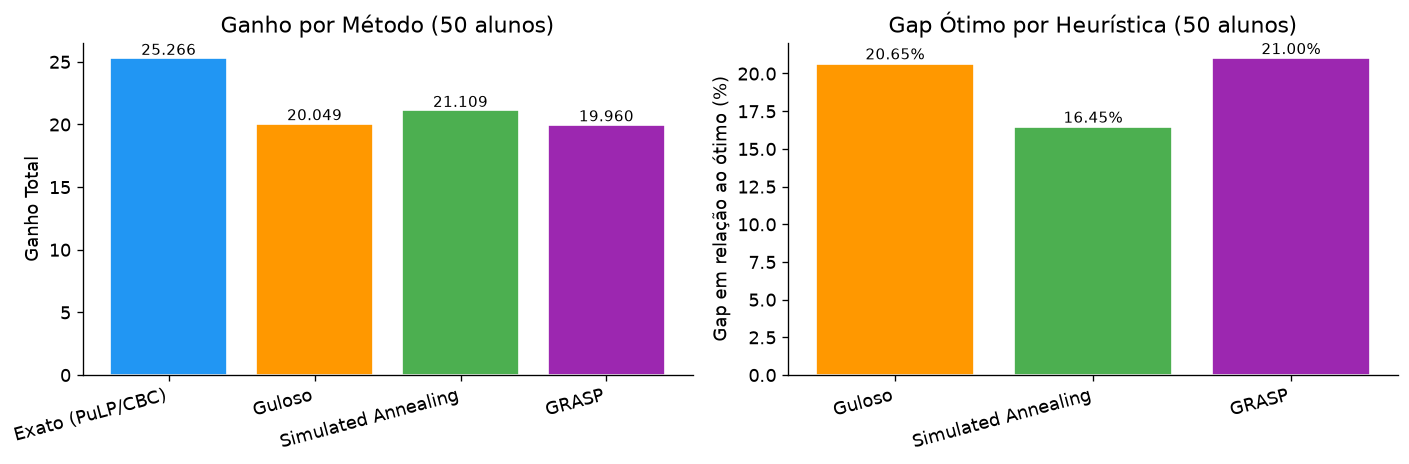

Salvo: data/figura_ganho_gap.png


In [4]:
# ============================================================
# Figura 1 — Comparação de ganho (barras) — instância 50 alunos
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metodos = tabela_50['Método']
ganhos  = tabela_50['Ganho Total']
colors  = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

# Barras de ganho
bars = axes[0].bar(metodos, ganhos, color=colors, edgecolor='white')
axes[0].set_ylabel('Ganho Total')
axes[0].set_title('Ganho por Método (50 alunos)')
axes[0].set_xticklabels(metodos, rotation=15, ha='right')
for bar, v in zip(bars, ganhos):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Gap (%)
heur = tabela_50[tabela_50['Método'] != 'Exato (PuLP/CBC)']
bars2 = axes[1].bar(heur['Método'], heur['Gap Ótimo (%)'], color=colors[1:], edgecolor='white')
axes[1].set_ylabel('Gap em relação ao ótimo (%)')
axes[1].set_title('Gap Ótimo por Heurística (50 alunos)')
axes[1].set_xticklabels(heur['Método'], rotation=15, ha='right')
for bar, v in zip(bars2, heur['Gap Ótimo (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data/figura_ganho_gap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Salvo: data/figura_ganho_gap.png")

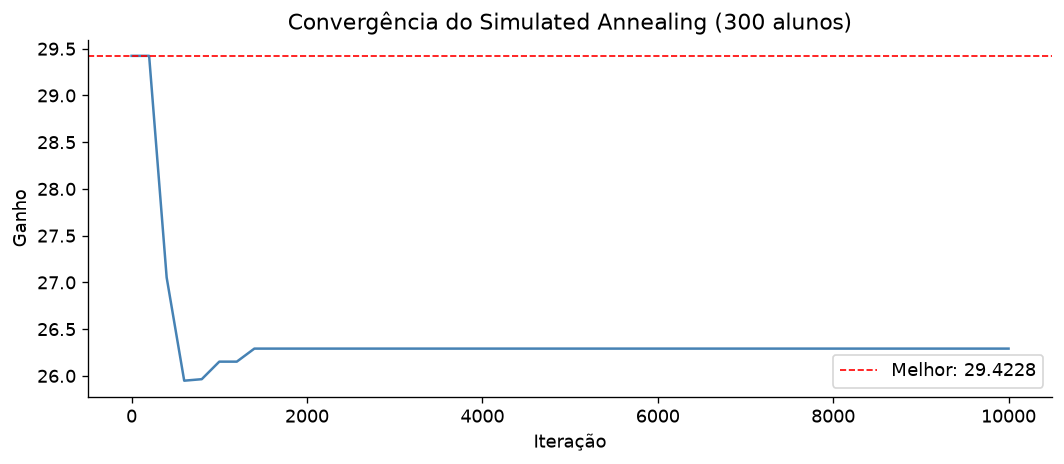

Salvo: data/figura_convergencia_sa.png


In [5]:
# ============================================================
# Figura 2 — Convergência do SA (300 alunos)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4))
iters = np.arange(len(hist_sa)) * 200
ax.plot(iters, hist_sa, color='steelblue', linewidth=1.5)
ax.axhline(y=max(hist_sa), color='red', linestyle='--', linewidth=1, label=f'Melhor: {max(hist_sa):.4f}')
ax.set_xlabel('Iteração')
ax.set_ylabel('Ganho')
ax.set_title('Convergência do Simulated Annealing (300 alunos)')
ax.legend()
plt.tight_layout()
plt.savefig('data/figura_convergencia_sa.png', dpi=120, bbox_inches='tight')
plt.show()
print("Salvo: data/figura_convergencia_sa.png")

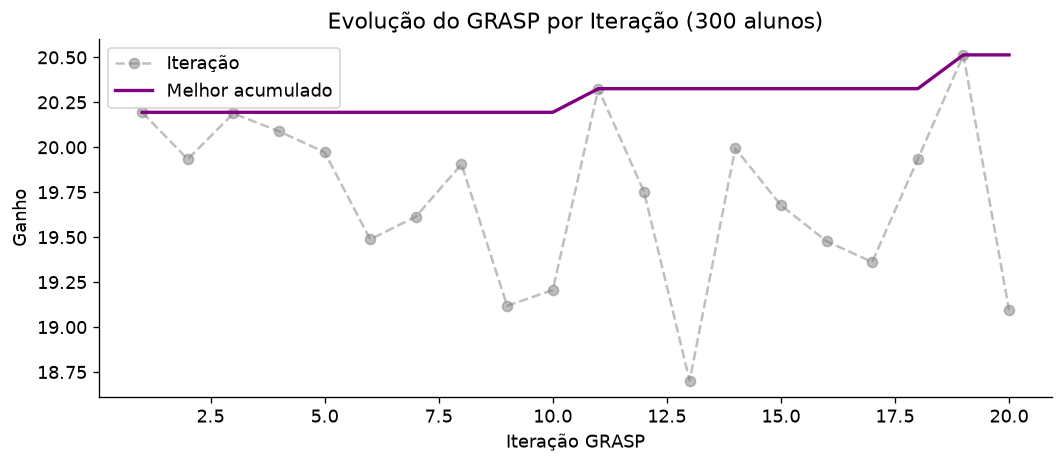

Salvo: data/figura_grasp.png


In [6]:
# ============================================================
# Figura 3 — Evolução do GRASP (melhor encontrado por iteração)
# ============================================================
melhor_acum = np.maximum.accumulate(hist_grasp)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(hist_grasp)+1), hist_grasp, 'o--', color='gray', alpha=0.5, label='Iteração')
ax.plot(range(1, len(melhor_acum)+1), melhor_acum, '-', color='purple', linewidth=2, label='Melhor acumulado')
ax.set_xlabel('Iteração GRASP')
ax.set_ylabel('Ganho')
ax.set_title('Evolução do GRASP por Iteração (300 alunos)')
ax.legend()
plt.tight_layout()
plt.savefig('data/figura_grasp.png', dpi=120, bbox_inches='tight')
plt.show()
print("Salvo: data/figura_grasp.png")

  B= 5 → Guloso=7.4142
  B=10 → Guloso=14.7896
  B=15 → Guloso=22.1178
  B=20 → Guloso=29.4228
  B=25 → Guloso=36.7176
  B=30 → Guloso=43.9649
  B=35 → Guloso=51.1619
  B=40 → Guloso=58.3320
  B=45 → Guloso=65.4368
  B=50 → Guloso=72.5080


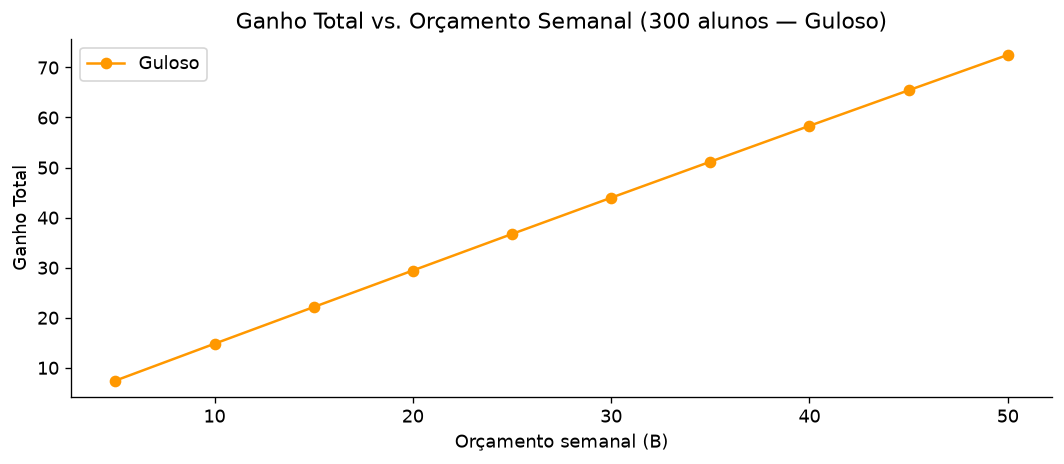

Salvo: data/figura_ganho_orcamento.png


In [7]:
# ============================================================
# Figura 4 — Ganho × Orçamento (análise de sensibilidade)
# Simulamos variando B (budget por semana) e re-executando o guloso
# ============================================================
import sys, os
sys.path.insert(0, '.')

gains_df = pd.read_csv('data/gains.csv')
TIPOS = ['R1_email', 'R2_tutor', 'R3_recuperacao']
INTERVENCOES = {
    'R1_email': {'custo': 1},
    'R2_tutor': {'custo': 5},
    'R3_recuperacao': {'custo': 2},
}
N_SEMANAS = 10
MAX_INTERV_ALUNO = 3

todos_usuarios = sorted(gains_df['username'].unique())

def build_gain_matrix_fast(usuarios):
    sub = gains_df[gains_df['username'].isin(usuarios)]
    gain = {}
    for u in usuarios:
        gain[u] = {}
        for t in range(N_SEMANAS):
            gain[u][t] = {}
            for r in TIPOS:
                row = sub[(sub['username']==u) & (sub['semana']==t) & (sub['tipo_interv']==r)]
                gain[u][t][r] = float(row['gain'].values[0]) if len(row)>0 else 0.0
    return gain, {r: INTERVENCOES[r]['custo'] for r in TIPOS}

def guloso_budget(usuarios, gain, custo, budget):
    candidatos = [(gain[u][t][r]/custo[r], gain[u][t][r], custo[r], u, t, r)
                  for u in usuarios for t in range(N_SEMANAS) for r in TIPOS]
    candidatos.sort(reverse=True)
    budget_usado = [0]*N_SEMANAS
    interv_aluno = {u: 0 for u in usuarios}
    interv_sem_al = {(u,t): 0 for u in usuarios for t in range(N_SEMANAS)}
    total = 0.0
    for ratio, g, c, u, t, r in candidatos:
        if (budget_usado[t]+c<=budget and interv_aluno[u]<MAX_INTERV_ALUNO
                and interv_sem_al[(u,t)]==0):
            budget_usado[t] += c
            interv_aluno[u] += 1
            interv_sem_al[(u,t)] += 1
            total += g
    return total

gain_mat, custo_mat = build_gain_matrix_fast(todos_usuarios)
budgets = list(range(5, 55, 5))
ganhos_por_budget = {m: [] for m in ['Guloso']}

for b in budgets:
    ganhos_por_budget['Guloso'].append(guloso_budget(todos_usuarios, gain_mat, custo_mat, b))
    print(f"  B={b:2d} → Guloso={ganhos_por_budget['Guloso'][-1]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(budgets, ganhos_por_budget['Guloso'], 'o-', color='#FF9800', label='Guloso')
ax.set_xlabel('Orçamento semanal (B)')
ax.set_ylabel('Ganho Total')
ax.set_title('Ganho Total vs. Orçamento Semanal (300 alunos — Guloso)')
ax.legend()
plt.tight_layout()
plt.savefig('data/figura_ganho_orcamento.png', dpi=120, bbox_inches='tight')
plt.show()
print("Salvo: data/figura_ganho_orcamento.png")

In [8]:
print("\n" + "="*70)
print("RESUMO DOS RESULTADOS")
print("="*70)
print("\n[Instância: 50 alunos — comparação com ótimo]")
print(tabela_50.to_string(index=False))
print("\n[Instância: 300 alunos — heurísticas]")
print(tabela_300.to_string(index=False))
print("\nGráficos salvos em data/")


RESUMO DOS RESULTADOS

[Instância: 50 alunos — comparação com ótimo]
             Método  Ganho Total  Gap Ótimo (%)  Tempo (s)
   Exato (PuLP/CBC)      25.2660           0.00      0.714
             Guloso      20.0494          20.65      0.002
Simulated Annealing      21.1091          16.45      0.784
              GRASP      19.9603          21.00      1.901

[Instância: 300 alunos — heurísticas]
             Método  Ganho Total  Tempo (s)
             Guloso      29.4228      0.007
Simulated Annealing      29.4228      2.794
              GRASP      20.5131     19.780

Gráficos salvos em data/
